- O HDBSCAN usa uma abordagem "dura" baseada em densidade: ou um time pertence a um bairro, ou ele é ejetado como ruído (-1).

- O GMM, o qual será feito nesse notebook, usa uma abordagem probabilística "suave" (Soft Clustering). Ele assume que os dados não são feitos de caixas isoladas, mas sim de distribuições de probabilidade que se sobrepõem.

- O GMM exige que seja informado quantos clusters (K) ele deve procurar. Para não ser um chute esse número, será usado o Critério de Informação Bayesiano (BIC). O algoritmo testa vários valores de K e penaliza modelos complexos demais. O ponto mais baixo da curva do BIC indica o número matematicamente ideal de grupos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.mixture import GaussianMixture
import umap

# preparando os tres espaçoes (pra ficar igual o DBSCAN)

df_season = pd.read_parquet("../dim_redux/dados_reducao.parquet")

features = ['PF', 'PA', 'Off_Pass_Yds', 'Off_Rush_Yds', 'Off_Carries', 
            'Off_Turnovers', 'Def_Sacks_Produced', 'Def_Turnovers_Forced']

# espaço 1: 8D original escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_season[features])

# espaço 2: recalculando t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_scaled)
df_season['TSNE1'] = X_tsne[:, 0]
df_season['TSNE2'] = X_tsne[:, 1]

# espaço 3: recalculando UMAP
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42, metric='euclidean')
X_umap = reducer.fit_transform(X_scaled)
df_season['UMAP1'] = X_umap[:, 0]
df_season['UMAP2'] = X_umap[:, 1]

print("Espaços dimensionais preparados com sucesso!")
print(f"Dataset: {df_season.shape[0]} times/temporadas.")

/home/jean/NFL/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Espaços dimensionais preparados com sucesso!
Dataset: 160 times/temporadas.


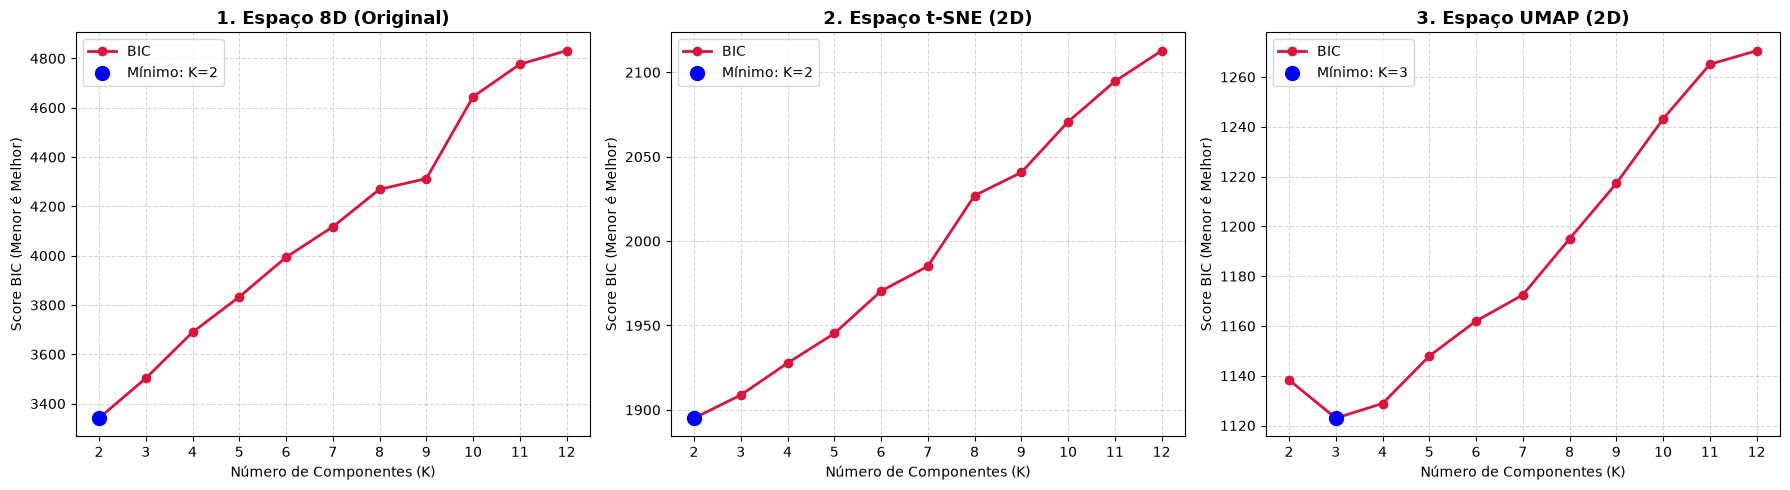

In [2]:
# selecionando o numero de componentes nos espaçoes (BIC)

def calcular_bic_aic(X, k_range=range(2, 13)):
    bic_scores = []
    aic_scores = []
    for k in k_range:
        gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
        gmm.fit(X)
        bic_scores.append(gmm.bic(X))
        aic_scores.append(gmm.aic(X))
    return bic_scores, aic_scores

k_range = list(range(2, 13))
bic_8d, aic_8d = calcular_bic_aic(X_scaled, k_range)
bic_tsne, aic_tsne = calcular_bic_aic(X_tsne, k_range)
bic_umap, aic_umap = calcular_bic_aic(X_umap, k_range)

# plotando as curvas comparativas de BIC
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

espacos = [
    ('1. Espaço 8D (Original)', bic_8d, axes[0]),
    ('2. Espaço t-SNE (2D)', bic_tsne, axes[1]),
    ('3. Espaço UMAP (2D)', bic_umap, axes[2])
]

for title, scores, ax in espacos:
    ax.plot(k_range, scores, marker='o', color='crimson', linewidth=2, label='BIC')
    # marca o ponto de mínimo
    k_min = k_range[np.argmin(scores)]
    min_score = min(scores)
    ax.scatter([k_min], [min_score], color='blue', s=100, zorder=5, label=f'Mínimo: K={k_min}')
    
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Número de Componentes (K)')
    ax.set_ylabel('Score BIC (Menor é Melhor)')
    ax.set_xticks(k_range)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend()

plt.tight_layout()
plt.show()

- Visão Binária do 8D e do t-SNE (K=2):
    - Tanto no espaço original quanto no t-SNE, a matemática enxergou a NFL de forma puramente binária. Ele dividiu a liga em duas grandes "massas" (provavelmente algo como "Times Positivos" vs "Times Negativos", ou "Focados no Passe" vs "Focados na Corrida").

- O Triunfo do UMAP (K=3):
    - Mais uma vez, o UMAP provou sua superioridade topológica. Mesmo sob a rigorosa penalidade do BIC, ele conseguiu preservar estrutura suficiente para forçar a matemática a reconhecer 3 Super-Clusters em vez de apenas 2, identificando que a polarização binária não explica a NFL por completo e que existe uma terceira grande "família" tática.

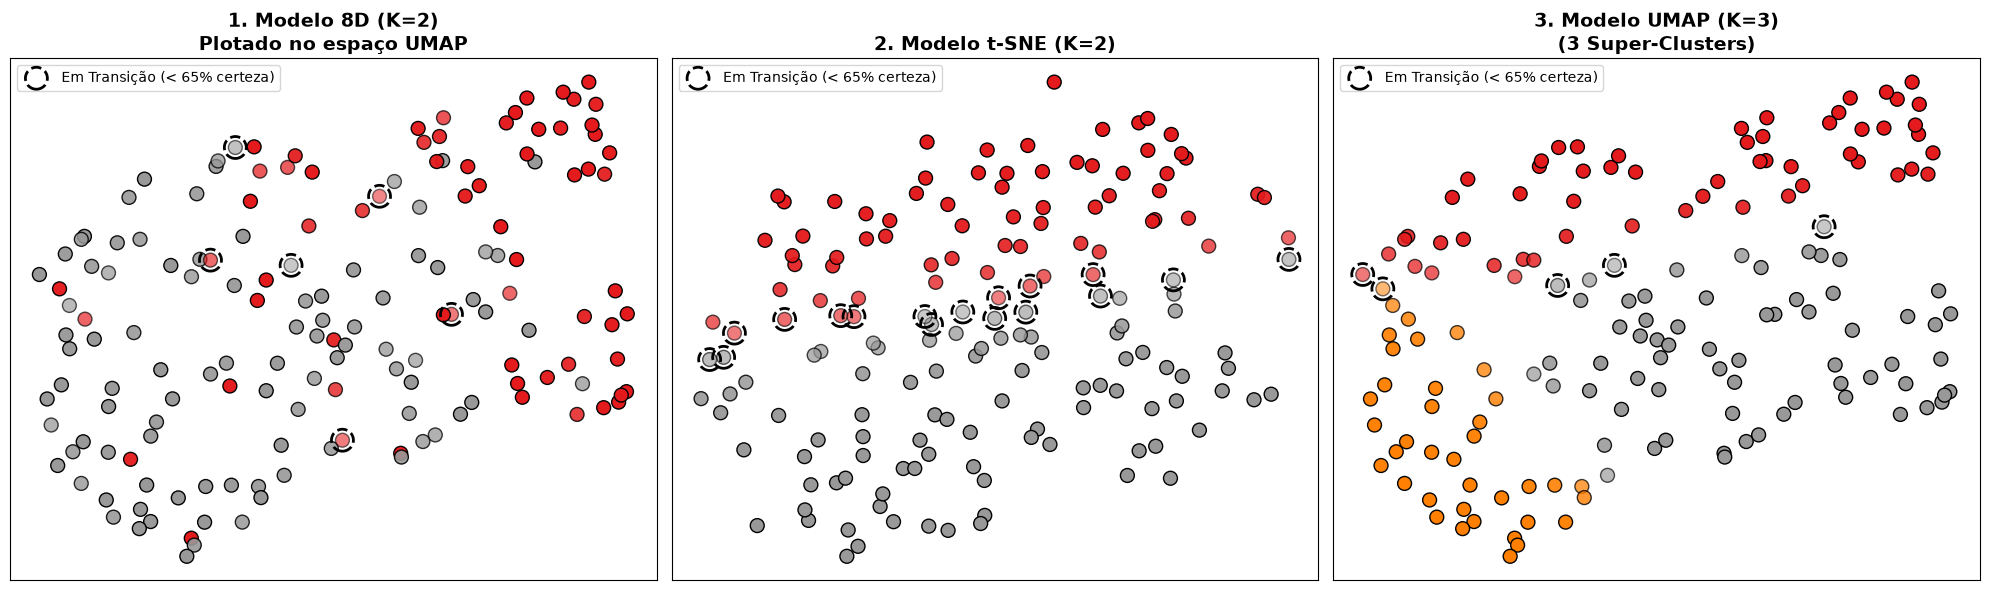

In [3]:
# aplicação do GMM e análise de confiança (Soft Clustering)

# ajustando os modelos com os valores ótimos de K encontrados no BIC
gmm_8d = GaussianMixture(n_components=2, covariance_type='full', random_state=42)
df_season['GMM_Cluster_8D'] = gmm_8d.fit_predict(X_scaled)
df_season['GMM_Confianca_8D'] = np.max(gmm_8d.predict_proba(X_scaled), axis=1)

gmm_tsne = GaussianMixture(n_components=2, covariance_type='full', random_state=42)
df_season['GMM_Cluster_TSNE'] = gmm_tsne.fit_predict(X_tsne)
df_season['GMM_Confianca_TSNE'] = np.max(gmm_tsne.predict_proba(X_tsne), axis=1)

gmm_umap = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
df_season['GMM_Cluster_UMAP'] = gmm_umap.fit_predict(X_umap)
df_season['GMM_Confianca_UMAP'] = np.max(gmm_umap.predict_proba(X_umap), axis=1)

# função para plotar com opacidade baseada na confiança
def plot_gmm_soft_clustering(x_coords, y_coords, cluster_labels, confianca, ax, titulo):
    # times com alta certeza ficam sólidos/claros, times com baixa certeza ficam desbotados/borrados
    scatter = ax.scatter(x_coords, y_coords, c=cluster_labels, cmap='Set1', 
                         s=100, alpha=confianca, edgecolors='black', linewidths=1)
    
    # destacando os "Times em Transição" (Confiança < 65%)
    transicao_idx = confianca < 0.65
    if transicao_idx.sum() > 0:
        ax.scatter(x_coords[transicao_idx], y_coords[transicao_idx], 
                   facecolors='none', edgecolors='black', s=250, linewidths=2, 
                   linestyle='--', label='Em Transição (< 65% certeza)')
        ax.legend(loc='best')
        
    ax.set_title(titulo, fontsize=14, fontweight='bold')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(True, linestyle='--', alpha=0.3)

# plotando as 3 visões
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# obs: foram plotadas as labels do 8D sobre a projeção do UMAP para visualizar como a matemática do 8D separou os times
plot_gmm_soft_clustering(df_season['UMAP1'], df_season['UMAP2'], df_season['GMM_Cluster_8D'], df_season['GMM_Confianca_8D'], axes[0], '1. Modelo 8D (K=2)\nPlotado no espaço UMAP')
plot_gmm_soft_clustering(df_season['TSNE1'], df_season['TSNE2'], df_season['GMM_Cluster_TSNE'], df_season['GMM_Confianca_TSNE'], axes[1], '2. Modelo t-SNE (K=2)')
plot_gmm_soft_clustering(df_season['UMAP1'], df_season['UMAP2'], df_season['GMM_Cluster_UMAP'], df_season['GMM_Confianca_UMAP'], axes[2], '3. Modelo UMAP (K=3)\n(3 Super-Clusters)')

plt.tight_layout()
plt.show()

- Sobre o modelo 8D, pode-se ver que apesar de haver uma tendencia geral de clusterização (vermelhas pro canto superior direito, e cinzas pro inferior esquerdo), essa clusterização é bem franca e confusa, havendo vários pontos vermelhos espalhados em qualquer área do gráfico, assim como pontos cinzas também estão espalhados, oque mostra que o GMM também enfrenta dificuldades pela alta dimensionalidade dos dados brutos.

- Sobre o t-SNE, ele eliminou o ruído e a sobreposição confusa que foi observada no 8D. O GMM conseguiu fatiar o espaço topológico de forma bem mais limpa: uma massa consolidada no topo (Vermelho) e outra na base (Cinza), com os times em transição (circulos tracejados) claramente dividindo os dois clusters, o modelo conseguiu mapear bem a "zona de conflito" onde a identidade de um grupo termina e a do outro começa. Embora a matemática tenha funcionado para separar os dados, cortar a NFL apenas em "Metade de Cima" e "Metade de Baixo" parece ser uma visão simplista demais para tirar insights de valor (refletindo a miopia estrutural do t-SNE, notada no HDBSCAN).

- Sobre o UMAP, é visível a diminuição dos pontos tracejados, isso indica que o UMAP organizou os dados em "ilhas"/clusters de densidade muito mais puras. Como a matemática do algoritmo encontrou grupos mais coesos e menos sobrepostos, o modelo conseguiu classificar a maioria da liga com mais de 65% de probabilidade. O GMM consolidou as 7 micro-categorias do HDBSCAN em 3 grandes "filosofias" de franquias. Os raríssimos círculos tracejados que restaram não estão espalhados aleatoriamente, eles ocorrem exatamente nos pontos onde as três cores se encontram. Uma equipe posicionada ali provavelmente é uma franquia genuinamente híbrida, executando uma transição tática no meio da temporada ou sofrendo de uma crise de identidade que mistura elementos de duas famílias diferentes.

In [7]:
import matplotlib as mpl
import matplotlib.colors as mcolors
from IPython.display import HTML, display

# perfilamento dos clusters do GMM

# agrupamento das médias originais pelos Clusters do GMM no t-SNE (K=2)
perfil_gmm_tsne = df_season.groupby('GMM_Cluster_TSNE')[features].mean().round(1)
perfil_gmm_tsne['Qtd_Times'] = df_season.groupby('GMM_Cluster_TSNE').size()

# agrupamento das médias originais pelos clusters do GMM no UMAP (K=3)
perfil_gmm_umap = df_season.groupby('GMM_Cluster_UMAP')[features].mean().round(1)
perfil_gmm_umap['Qtd_Times'] = df_season.groupby('GMM_Cluster_UMAP').size()

# configuração visual HTML
cmap = mpl.colormaps['Set1']
norm_tsne = mcolors.Normalize(vmin=0, vmax=1)
norm_umap = mcolors.Normalize(vmin=0, vmax=2)

def aplicar_cor_tsne(val):
    cor_hex = mcolors.to_hex(cmap(norm_tsne(val)))
    return f'<span style="color: {cor_hex}; font-size: 1.5em;">⬤</span> Família {val}'

def aplicar_cor_umap(val):
    cor_hex = mcolors.to_hex(cmap(norm_umap(val)))
    return f'<span style="color: {cor_hex}; font-size: 1.5em;">⬤</span> Família {val}'

# resetando o index para que a coluna do cluster receba o estilo HTML
perfil_gmm_tsne = perfil_gmm_tsne.reset_index()
perfil_gmm_umap = perfil_gmm_umap.reset_index()

perfil_gmm_tsne['GMM_Cluster_TSNE'] = perfil_gmm_tsne['GMM_Cluster_TSNE'].apply(aplicar_cor_tsne)
perfil_gmm_umap['GMM_Cluster_UMAP'] = perfil_gmm_umap['GMM_Cluster_UMAP'].apply(aplicar_cor_umap)

print("\n--- PERFIL GMM t-SNE (2 Metades) ---")
display(HTML(perfil_gmm_tsne.to_html(escape=False, index=False, justify='center')))

print("--- PERFIL GMM UMAP (3 Super-Clusters) ---")
display(HTML(perfil_gmm_umap.to_html(escape=False, index=False, justify='center')))


--- PERFIL GMM t-SNE (2 Metades) ---


GMM_Cluster_TSNE,PF,PA,Off_Pass_Yds,Off_Rush_Yds,Off_Carries,Off_Turnovers,Def_Sacks_Produced,Def_Turnovers_Forced,Qtd_Times
⬤ Família 0,330.0,405.1,3889.6,1722.1,419.8,23.8,39.6,19.4,69
⬤ Família 1,422.1,365.2,4060.0,2196.1,485.6,19.7,42.0,23.0,91


--- PERFIL GMM UMAP (3 Super-Clusters) ---


GMM_Cluster_UMAP,PF,PA,Off_Pass_Yds,Off_Rush_Yds,Off_Carries,Off_Turnovers,Def_Sacks_Produced,Def_Turnovers_Forced,Qtd_Times
⬤ Família 0,434.8,360.8,4388.5,1949.8,452.1,19.9,43.8,25.8,56
⬤ Família 1,306.2,419.3,3707.9,1699.3,416.2,26.2,39.1,17.7,38
⬤ Família 2,381.9,379.5,3805.8,2195.5,485.2,20.1,39.6,20.0,66


- Sobre o t-SNE:
    - Família 0 (Vermelho): este grupo representa as equipes que executam os fundamentos do esporte. Eles dominam o controle de relógio pelo chão (485.6 corridas para 2.196 jardas) e pontuam muito bem (422.1 PF), enquanto sofrem menos pontuação (365.2 PA). Mais importante, eles respeitam a posse de bola (19.7 turnovers cometidos) enquanto a defesa atua de forma oportunista (23.0 turnovers forçados). É o retrato adequado das regras de associação do FP-Growth: correr com a bola + proteger a posse = sucesso.
    - Família 1 (Cinza): é a materialização estatística da ineficiência. O ataque é manco, tendo o jogo terrestre frquíssimo (apenas 419 corridas e 1.722 jardas) e cometendo muitos erros (23.8 turnovers). A defesa reflete essa bagunça, cedendo altos 405.1 pontos e falhando em gerar posses extras (apenas 19.4 turnovers forçados).
    - Os números são claros, mas é notável a miopia tática de usar apenas 2 clusters. Ao jogar 91 times (quase 60% do dataset) no Cluster 0, a matemática misturou franquias medianas competentes com dinastias de Super Bowl na mesma bacia.

- Sobre o UMAP: 
    - Família 0 (Vermelho): Com 56 times, este é o topo absoluto da cadeia alimentar. Eles destroem as defesas pelo ar (absurdas 4.388 jardas de passe) e lideram a liga em pontuação (434.8 PF). No entanto, o verdadeiro diferencial é a defesa: eles geram o caos. Lideram em sacks (43.8) e turnovers forçados (25.8). É a consolidação dos bairros "Olimpo" e "Canhões de Vidro" do HDBSCAN: ataques letais apoiados por defesas que roubam a bola.
    - Família 2 (Cinza): Com 66 times, este grupo é a prova de que correr com a bola ainda garante sobrevivência. Eles lideram a NFL em volume terrestre (485 carregadas para 2.195 jardas). O ataque aéreo é moderado (3.805 jardas), mas eles protegem muito bem a bola (20.1 turnovers cometidos) e mantêm um saldo de pontos levemente positivo (381 PF vs 379 PA). São os times "operários" que vencem controlando o relógio.
    - Família 1 (Laranja): Com 38 times, esta é a verdadeira fossa da liga. O ataque é anêmico (apenas 306 PF, último em jardas aéreas e terrestres) e comete erros fatais (26.2 turnovers). A defesa é uma peneira, cedendo absurdos 419 pontos e falhando em forçar erros do adversário (apenas 17.7 turnovers forçados).

- Apenas pra observas os times transicionais do UMAP:

In [10]:
# extração das porcentagens de transição (Soft Clustering)

# filtrando os times que estão na fronteira de incerteza do UMAP (< 65% de confiança)
limiar_incerteza = 0.65
transicao_idx = df_season['GMM_Confianca_UMAP'] < limiar_incerteza

print(f"\n--- ANÁLISE DE TRANSIÇÃO TÁTICA UMAP (< {limiar_incerteza*100}% de Confiança) ---")

# pegando as probabilidades exatas brutas (matriz de N times x 3 Clusters)
probs_transicao = gmm_umap.predict_proba(X_umap[transicao_idx])

# iterando sobre esses times específicos para gerar o diagnóstico
df_transicao = df_season[transicao_idx]

for i, (_, row) in enumerate(df_transicao.iterrows()):
    p_0, p_1, p_2 = probs_transicao[i] * 100
    print(f"{row['team']} ({row['season']}): {p_0:.1f}% Família 0 | {p_1:.1f}% Família 1 | {p_2:.1f}% Família 2")


--- ANÁLISE DE TRANSIÇÃO TÁTICA UMAP (< 65.0% de Confiança) ---
IND (2023): 45.8% Família 0 | 0.0% Família 1 | 54.2% Família 2
JAX (2023): 42.3% Família 0 | 54.1% Família 1 | 3.6% Família 2
MIA (2023): 46.3% Família 0 | 0.0% Família 1 | 53.7% Família 2
MIN (2023): 58.8% Família 0 | 39.3% Família 1 | 1.9% Família 2
DEN (2024): 34.8% Família 0 | 0.4% Família 1 | 64.7% Família 2


- Miami Dolphins (2023) e Indianapolis Colts (2023) — (Família 0 ↔ Família 2): Ambos estão divididos em proporções parecidas (MIA com 53.7% na base terrestre e 46.3% na elite). A matemática capturou o esquema tático moderno de técnicos ofensivos como Mike McDaniel em Miami, e Shane Steichen, em Indianapolis, times que dominam o chão e o controle de relógio (Família 2), mas também possuem explosão de jardas, pontuação e agressividade que beiram o teto da Elite Aérea (Família 0). Nota-se que ambos têm 0.0% de chance de pertencer à fossa do Colapso Estrutural. O Dolphins terminou com 11V-6D, e o Colts com 9V-8D.

- Jacksonville Jaguars (2023) — O "Boom or Bust" (Família 0 ↔ Família 1): O caso mais instável do mapa. Dividido entre a Elite (42.3%) e o Colapso Absoluto (54.1%), sem nenhum traço de jogo operário/terrestre (apenas 3.6%). É a definição matemática de um time "canhão de vidro": passa muito a bola e tem picos de alta pontuação, mas é frequentemente sabotado por turnovers catastróficos e apagões defensivos que o puxam de volta para a mediocridade. O Jaguars terminou com 9V-8D.

- Minnesota Vikings (2023) — A Elite Ferida (Família 0 ↔ Família 1): Puxa predominantemente para a Elite Aérea (58.8%), refletindo um alto volume de passes e produção de recebedores, mas possui uma âncora gigantesca no Colapso Estrutural (39.3%). Historicamente, isso espelha campanhas que produzem números aéreos maravilhosos, mas perdem jogos por não conseguirem proteger a bola ou devido a falhas críticas da defesa. O Jaguars terminou com 7V-10D.

- Denver Broncos (2024) — O Operário em Ascensão (Família 2 ↔ Família 0): Quase consolidado como Classe Média Terrestre (bateu na trave da nota de corte com 64.7%), mas flertando fortemente (34.8%) com a Elite. Mostra uma franquia de fundação conservadora e terrestre que encontrou eficiência o suficiente no passe ou na geração de turnovers defensivos para começar a ameaçar os números do topo da liga. O Broncos terminou com 10V-7D.